# Portfolio comparison with and without lot constraints

This notebook compares two approaches to portfolio construction for 5 MOEX stocks:

1. **Continuous portfolio** — weights are selected as if fractional shares were allowed.
2. **Lot-constrained portfolio** — the portfolio is formed using integer numbers of MOEX lots.

The estimation is based on **daily returns**.

**Tickers:** `LKOH`, `GAZP`, `SBER`, `AKRN`, `GMKN`  
**Estimation period:** `2024-01-01` to `2026-04-20`  
**Portfolio formation date:** `2026-04-20`  
**Budget:** `1,000,000 RUB`

In [ ]:

import requests
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from itertools import product

pd.set_option("display.float_format", "{:,.6f}".format)

# List of stock tickers
tickers = ["LKOH", "GAZP", "SBER", "AKRN", "GMKN"]

# Base URL of the MOEX ISS API
iss_url = "https://iss.moex.com/iss/history/engines/stock/markets/shares/boards/tqbr/securities/"

# Time period for data collection
start_date = "2024-01-01"
end_date = "2026-04-20"
as_of_date = "2026-04-20"

# Portfolio budget
budget = 1_000_000

# Number of trading days for optional annualization
trading_days = 252

## 1. Lot size parser


In [ ]:
# URL to retrieve stock data for the TQBR trading board (MOEX main market)
url = 'https://iss.moex.com/iss/engines/stock/markets/shares/boards/TQBR/securities.json'

# Request parameters:
# disable metadata and select only relevant fields
params = {
    'iss.meta': 'off',
    'securities.columns': 'SECID,LOTSIZE,SHORTNAME'
}

# Send request to the MOEX ISS API
response = requests.get(url, params=params)

# Parse JSON response
data = response.json()

# Convert the data into a pandas DataFrame
securities_data = pd.DataFrame(
    data['securities']['data'],
    columns=data['securities']['columns']
)

# Display selected columns: ticker, company name, and lot size
securities_data[['SECID', 'SHORTNAME', 'LOTSIZE']].head()

,SECID,SHORTNAME,LOTSIZE
0,ABIO,iАРТГЕН ао,10
1,ABRD,АбрауДюрсо,10
2,AFKS,Система ао,100
3,AFLT,Аэрофлот,10
4,AKRN,Акрон,1


## 2. Historical price parser


In [ ]:
# Pagination parameter:
# the API returns data in portions ("pages"), so we request it step by step
batch_size = 100  # Maximum number of records returned per API request

# Container for storing downloaded quote data
data = []

# Function to retrieve stock quotes with pagination
def get_stock_quotes(ticker):
    # 'start' defines the starting position for pagination:
    # for example, start = 0 means "give me the first batch_size records starting from row 0"
    start = 0

    while True:
        url = f"{iss_url}{ticker}.json?from={start_date}&till={end_date}&start={start}"
        response = requests.get(url)

        # Check whether the request was successful
        if response.status_code != 200:
            print(f"Error retrieving data for {ticker}: {response.status_code}")
            break

        json_data = response.json()

        try:
            quotes = json_data["history"]["data"]

            # Stop the loop if no more data is available
            if not quotes:
                break

            for quote in quotes:
                record = {
                    # Creating a record using selected fields
                    # Python uses zero-based indexing
                    # TRADEDATE -> trading date
                    # SECID     -> ticker
                    # CLOSE     -> closing price
                    "TRADEDATE": quote[1],
                    "SECID": quote[3],
                    "CLOSE": quote[11],   # CLOSE field in MOEX history block
                }
                data.append(record)

            # 'history.cursor' contains pagination metadata
            cursor = json_data["history.cursor"]

            # Check whether we have reached the end of available data
            if cursor["data"][0][0] >= cursor["data"][0][1]:
                break

            # Move to the next page
            start = cursor["data"][0][0] + batch_size

        except KeyError as e:
            print(f"Error processing data for {ticker}: {e}")
            break

# Download data for each ticker
for ticker in tickers:
    get_stock_quotes(ticker)

# Create a DataFrame and reshape it into a pivot table
if data:
    d1 = pd.DataFrame(data)

    d1["TRADEDATE"] = pd.to_datetime(d1["TRADEDATE"])
    d1["CLOSE"] = pd.to_numeric(d1["CLOSE"], errors="coerce")

    filtered_df = d1.pivot_table(
        index="TRADEDATE",
        columns="SECID",
        values="CLOSE",
        fill_value=np.nan
    )

    # Sort dates in ascending order for return calculations
    filtered_df = filtered_df.sort_index(ascending=True)

    # Preserve the original ticker order
    filtered_df = filtered_df[tickers]

    print("Price matrix:")
    display(filtered_df.tail())
else:
    print("No data was retrieved.")

Price matrix:


SECID,LKOH,GAZP,SBER,AKRN,GMKN
TRADEDATE,,,,,
2026-04-14,"5,414.000000",127.900000,317.110000,"19,834.000000",132.020000
2026-04-15,"5,410.500000",128.500000,320.910000,"19,966.000000",134.200000
2026-04-16,"5,368.500000",127.560000,322.160000,"20,342.000000",136.160000
2026-04-17,"5,308.000000",124.680000,323.870000,"20,056.000000",137.680000
2026-04-20,"5,392.500000",125.830000,325.300000,"20,228.000000",139.220000


## 3. Lot sizes and purchase prices

Now we prepare a small table with:
- lot size,
- purchase price on the portfolio formation date,
- value of one lot in RUB.

In [ ]:

# Keep only the 5 selected stocks
lot_info = securities_data[securities_data["SECID"].isin(tickers)].copy()
lot_info["LOTSIZE"] = pd.to_numeric(lot_info["LOTSIZE"], errors="coerce")
lot_info = lot_info.set_index("SECID").loc[tickers]

# Latest available prices on or before the selected date
purchase_prices = filtered_df.loc[filtered_df.index <= pd.to_datetime(as_of_date)].iloc[-1]

lot_info["PRICE"] = purchase_prices
lot_info["LOT_VALUE"] = lot_info["LOTSIZE"] * lot_info["PRICE"]

display(lot_info[["SHORTNAME", "LOTSIZE", "PRICE", "LOT_VALUE"]])

,SHORTNAME,LOTSIZE,PRICE,LOT_VALUE
SECID,,,,
LKOH,ЛУКОЙЛ,1,"5,392.500000","5,392.500000"
GAZP,ГАЗПРОМ ао,10,125.830000,"1,258.300000"
SBER,Сбербанк,1,325.300000,325.300000
AKRN,Акрон,1,"20,228.000000","20,228.000000"
GMKN,ГМКНорНик,10,139.220000,"1,392.200000"


## 4. Daily returns

We estimate portfolio inputs from **daily returns**:
- expected daily return,
- daily covariance matrix.

In [ ]:

returns = filtered_df.pct_change().dropna()
returns = returns[tickers]

mu_daily = returns.mean()
cov_daily = returns.cov()

print("Expected daily returns:")
display(mu_daily.to_frame("mu_daily"))

print("Daily covariance matrix:")
display(cov_daily)

Expected daily returns:


/tmp/ipykernel_8050/1711937976.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = filtered_df.pct_change().dropna()


,mu_daily
SECID,
LKOH,-0.000270
GAZP,-0.000217
SBER,0.000388
AKRN,0.000154
GMKN,-0.001776


Daily covariance matrix:


SECID,LKOH,GAZP,SBER,AKRN,GMKN
SECID,,,,,
LKOH,0.000256,0.000192,0.000121,0.000031,0.000146
GAZP,0.000192,0.000425,0.000177,0.000039,0.000281
SBER,0.000121,0.000177,0.000197,0.000025,0.000178
AKRN,0.000031,0.000039,0.000025,0.000069,0.000037
GMKN,0.000146,0.000281,0.000178,0.000037,0.002136


## 5. Continuous portfolio (without lot constraints)

This is the standard long-only portfolio optimization:
- weights sum to 1,
- no short selling,
- fractional allocation is allowed.

In [ ]:
def portfolio_return(weights, mu):
    return float(np.dot(weights, mu))

def portfolio_volatility(weights, cov):
    return float(np.sqrt(weights @ cov @ weights))

def negative_sharpe_ratio(weights, mu, cov, rf=0.0):
    ret = portfolio_return(weights, mu)
    vol = portfolio_volatility(weights, cov)
    if vol == 0:
        return 1e9
    return -((ret - rf) / vol)

def optimize_continuous_portfolio(mu, cov):
    n = len(mu)
    x0 = np.repeat(1 / n, n)

    bounds = [(0, 1)] * n
    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]

    result = minimize(
        negative_sharpe_ratio,
        x0=x0,
        args=(mu.values, cov.values),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    if not result.success:
        raise RuntimeError(result.message)

    return pd.Series(result.x, index=mu.index, name="continuous_weight")

w_cont = optimize_continuous_portfolio(mu_daily, cov_daily)
display(w_cont.to_frame())

,continuous_weight
SECID,
LKOH,0.000000
GAZP,0.000000
SBER,0.524382
AKRN,0.475618
GMKN,0.000000


## 6. Continuous allocation in RUB

This table shows the theoretical portfolio if fractional shares were possible.

In [ ]:

continuous_alloc = pd.DataFrame(index=tickers)
continuous_alloc["continuous_weight"] = w_cont
continuous_alloc["target_rub"] = continuous_alloc["continuous_weight"] * budget
continuous_alloc["price"] = purchase_prices
continuous_alloc["lot_size"] = lot_info["LOTSIZE"]
continuous_alloc["lot_value"] = lot_info["LOT_VALUE"]
continuous_alloc["implied_lots"] = continuous_alloc["target_rub"] / continuous_alloc["lot_value"]

display(continuous_alloc)

,continuous_weight,target_rub,price,lot_size,lot_value,implied_lots
LKOH,0.000000,0.000000,"5,392.500000",1,"5,392.500000",0.000000
GAZP,0.000000,0.000000,125.830000,10,"1,258.300000",0.000000
SBER,0.524382,"524,381.562853",325.300000,1,325.300000,"1,611.993738"
AKRN,0.475618,"475,618.437147","20,228.000000",1,"20,228.000000",23.512875
GMKN,0.000000,0.000000,139.220000,10,"1,392.200000",0.000000


## 7. Lot-constrained portfolio

Now we form a realistic portfolio using **integer numbers of lots**.

The idea is simple:
1. take the continuous solution,
2. compute implied lot counts,
3. search around nearby integer values,
4. keep the feasible portfolio with the best Sharpe ratio.

In [ ]:

def evaluate_discrete_portfolio(lot_counts, lot_values, mu, cov, budget):
    lot_counts = np.array(lot_counts, dtype=int)
    rub_alloc = lot_counts * lot_values
    total_cost = rub_alloc.sum()
    cash = budget - total_cost

    if total_cost <= 0 or total_cost > budget:
        return None

    weights = rub_alloc / budget

    port_ret = float(weights @ mu)
    port_vol = float(np.sqrt(weights @ cov @ weights))
    sharpe = port_ret / port_vol if port_vol > 0 else -np.inf

    return {
        "lot_counts": lot_counts,
        "rub_alloc": rub_alloc,
        "total_cost": total_cost,
        "cash": cash,
        "weights": weights,
        "return": port_ret,
        "vol": port_vol,
        "sharpe": sharpe
    }

def search_lot_constrained_portfolio(w_cont, lot_info, mu, cov, budget, radius=3):
    lot_values = lot_info.loc[tickers, "LOT_VALUE"].values
    implied_lots = (w_cont.values * budget) / lot_values

    candidate_ranges = []
    for x in implied_lots:
        low = max(0, int(np.floor(x)) - radius)
        high = int(np.ceil(x)) + radius
        candidate_ranges.append(range(low, high + 1))

    best = None

    for candidate in product(*candidate_ranges):
        result = evaluate_discrete_portfolio(
            lot_counts=candidate,
            lot_values=lot_values,
            mu=mu.values,
            cov=cov.values,
            budget=budget
        )

        if result is None:
            continue

        if best is None or result["sharpe"] > best["sharpe"]:
            best = result

    return best

best_discrete = search_lot_constrained_portfolio(
    w_cont=w_cont,
    lot_info=lot_info,
    mu=mu_daily,
    cov=cov_daily,
    budget=budget,
    radius=3
)

best_discrete

{'lot_counts': array([   0,    0, 1608,   23,    0]),
 'rub_alloc': array([     0. ,      0. , 523082.4, 465244. ,      0. ]),
 'total_cost': np.float64(988326.4),
 'cash': np.float64(11673.599999999977),
 'weights': array([0.       , 0.       , 0.5230824, 0.465244 , 0.       ]),
 'return': 0.00027462661545565956,
 'vol': 0.008997128746053277,
 'sharpe': 0.030523806339453417}

## 8. Comparison of the two portfolios

In [ ]:
comparison = pd.DataFrame(index=tickers)

comparison["continuous_weight"] = w_cont
comparison["continuous_rub"] = comparison["continuous_weight"] * budget

comparison["lot_size"] = lot_info["LOTSIZE"]
comparison["price"] = lot_info["PRICE"]
comparison["lot_value"] = lot_info["LOT_VALUE"]

comparison["discrete_lots"] = best_discrete["lot_counts"]
comparison["discrete_rub"] = best_discrete["rub_alloc"]
comparison["discrete_weight"] = best_discrete["weights"]

comparison["weight_diff"] = comparison["discrete_weight"] - comparison["continuous_weight"]

display(comparison)

,continuous_weight,continuous_rub,lot_size,price,lot_value,discrete_lots,discrete_rub,discrete_weight,weight_diff
LKOH,0.000000,0.000000,1,"5,392.500000","5,392.500000",0,0.000000,0.000000,-0.000000
GAZP,0.000000,0.000000,10,125.830000,"1,258.300000",0,0.000000,0.000000,-0.000000
SBER,0.524382,"524,381.562853",1,325.300000,325.300000,1608,"523,082.400000",0.523082,-0.001299
AKRN,0.475618,"475,618.437147",1,"20,228.000000","20,228.000000",23,"465,244.000000",0.465244,-0.010374
GMKN,0.000000,0.000000,10,139.220000,"1,392.200000",0,0.000000,0.000000,-0.000000


## 9. Portfolio metrics

The optimization is based on **daily data**, so the main metrics are daily.


In [ ]:

continuous_return_daily = portfolio_return(w_cont.values, mu_daily.values)
continuous_vol_daily = portfolio_volatility(w_cont.values, cov_daily.values)
continuous_sharpe_daily = continuous_return_daily / continuous_vol_daily

discrete_return_daily = best_discrete["return"]
discrete_vol_daily = best_discrete["vol"]
discrete_sharpe_daily = best_discrete["sharpe"]

summary = pd.DataFrame({
    "Portfolio": ["Continuous", "Lot-constrained"],
    "Expected daily return": [continuous_return_daily, discrete_return_daily],
    "Daily volatility": [continuous_vol_daily, discrete_vol_daily],
    "Daily Sharpe": [continuous_sharpe_daily, discrete_sharpe_daily],
    "Expected annual return (approx)": [continuous_return_daily * trading_days, discrete_return_daily * trading_days],
    "Annual volatility (approx)": [continuous_vol_daily * np.sqrt(trading_days), discrete_vol_daily * np.sqrt(trading_days)],
    "Invested capital (RUB)": [budget, best_discrete["total_cost"]],
    "Cash leftover (RUB)": [0, best_discrete["cash"]]
})

display(summary)

,Portfolio,Expected daily return,Daily volatility,Daily Sharpe,Expected annual return (approx),Annual volatility (approx),Invested capital (RUB),Cash leftover (RUB)
0,Continuous,0.000277,0.009066,0.030524,0.069736,0.143919,"1,000,000.000000",0.000000
1,Lot-constrained,0.000275,0.008997,0.030524,0.069206,0.142825,"988,326.400000","11,673.600000"


## 10. Extension: short selling and investment opportunity set

In this section we extend the notebook in two directions:

1. **Continuous portfolios with short selling**
2. **Discrete portfolios with short selling**

We also visualize the **investment opportunity set**.

### Why the discrete case is different

In the continuous model, portfolio weights can take any real values.

In the discrete model, positions must be represented by integer numbers of lots:

- positive lot count → long position,
- negative lot count → short position.

Because of this, the feasible set becomes non-smooth and non-convex.  
Therefore, for the discrete case we use a **simulation-based approximation**.

### Gross exposure


- long-only portfolios usually have gross exposure close to 1,
- long-short portfolios can have gross exposure above 1.

In this section we restrict the continuous and discrete short-selling portfolios by a gross exposure cap.


In [ ]:

# Optional plotting imports for the opportunity set chart
import matplotlib.pyplot as plt

try:
    from adjustText import adjust_text
except ImportError:
    adjust_text = None

RISK_FREE_RATE = 0.0

# Make sure the Sharpe function supports rf
def negative_sharpe_ratio(weights, mu, cov, rf=0.0):
    ret = portfolio_return(weights, mu)
    vol = portfolio_volatility(weights, cov)
    if vol <= 0:
        return 1e9
    return -((ret - rf) / vol)

# Inputs for the plotting / frontier section
mu_vec = mu_daily.values
cov_mat = cov_daily.values
tickers_plot = list(mu_daily.index)

print("Tickers used in the short-selling section:")
print(tickers_plot)


Tickers used in the short-selling section:
['LKOH', 'GAZP', 'SBER', 'AKRN', 'GMKN']


## 11. Continuous optimization helpers

The next block defines generic optimization functions used for:

- maximum Sharpe ratio portfolio,
- minimum-variance portfolio with target return,
- efficient frontier construction.

The same framework is used for both:

- **long-only portfolios**
- **portfolios with short selling**


In [ ]:

def get_bounds(n_assets, allow_short=False, weight_caps=None, tickers=None):
    """
    Build weight bounds for optimization.
    """
    if allow_short:
        bounds = [(-1.0, 1.0)] * n_assets
    else:
        bounds = [(0.0, 1.0)] * n_assets

    if weight_caps is not None and tickers is not None:
        new_bounds = []
        for i, t in enumerate(tickers):
            low, high = bounds[i]
            if t in weight_caps:
                high = min(high, weight_caps[t])
            new_bounds.append((low, high))
        bounds = new_bounds

    return bounds


def optimize_portfolio(
    mu_vector,
    cov_matrix,
    objective="max_sharpe",
    rf=0.0,
    allow_short=False,
    weight_caps=None,
    target_return=None,
    gross_limit=None,
    tickers=None
):
    """
    Generic portfolio optimizer for continuous portfolios.
    """
    mu_vector = np.asarray(mu_vector, dtype=float)
    cov_matrix = np.asarray(cov_matrix, dtype=float)
    n_assets = len(mu_vector)

    if tickers is None:
        tickers = [f"Asset_{i}" for i in range(n_assets)]

    x0 = np.repeat(1 / n_assets, n_assets)
    bounds = get_bounds(
        n_assets=n_assets,
        allow_short=allow_short,
        weight_caps=weight_caps,
        tickers=tickers
    )

    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0}
    ]

    if target_return is not None:
        constraints.append({
            "type": "eq",
            "fun": lambda w: portfolio_return(w, mu_vector) - target_return
        })

    if gross_limit is not None:
        constraints.append({
            "type": "ineq",
            "fun": lambda w: gross_limit - np.sum(np.abs(w))
        })

    if objective == "max_sharpe":
        result = minimize(
            negative_sharpe_ratio,
            x0=x0,
            args=(mu_vector, cov_matrix, rf),
            method="SLSQP",
            bounds=bounds,
            constraints=constraints
        )

    elif objective == "min_variance":
        result = minimize(
            lambda w, cov: portfolio_volatility(w, cov),
            x0=x0,
            args=(cov_matrix,),
            method="SLSQP",
            bounds=bounds,
            constraints=constraints
        )
    else:
        raise ValueError("Unknown objective. Use 'max_sharpe' or 'min_variance'.")

    if not result.success:
        raise RuntimeError(result.message)

    return result.x


def build_efficient_frontier(
    mu_vector,
    cov_matrix,
    allow_short=False,
    weight_caps=None,
    gross_limit=None,
    n_points=60,
    tickers=None
):
    target_returns = np.linspace(np.min(mu_vector), np.max(mu_vector), n_points)
    frontier_rows = []

    for target in target_returns:
        try:
            w = optimize_portfolio(
                mu_vector=mu_vector,
                cov_matrix=cov_matrix,
                objective="min_variance",
                rf=RISK_FREE_RATE,
                allow_short=allow_short,
                weight_caps=weight_caps,
                target_return=target,
                gross_limit=gross_limit,
                tickers=tickers
            )

            frontier_rows.append([
                portfolio_return(w, mu_vector),
                portfolio_volatility(w, cov_matrix)
            ])
        except Exception:
            continue

    return pd.DataFrame(frontier_rows, columns=["return", "volatility"])


## 12. Random continuous portfolios

To visualize the feasible sets, we generate many random portfolios.

- `allow_short=False` → long-only random portfolios
- `allow_short=True` → long-short random portfolios

For long-short portfolios we also control gross exposure.


In [ ]:

def simulate_random_portfolios(
    mu_vector,
    cov_matrix,
    n_assets,
    n_portfolios=12000,
    allow_short=False,
    gross_limit=None,
    random_state=42
):
    """
    Simulate random continuous portfolios.
    """
    rng = np.random.default_rng(random_state)
    rows = []

    for _ in range(n_portfolios):
        if allow_short:
            if gross_limit is None:
                gross_limit = 1.40

            max_short_share = max((gross_limit - 1.0) / 2.0, 0.0)
            s = rng.uniform(0.0, max_short_share)

            long_mix = rng.dirichlet(np.ones(n_assets))
            short_mix = rng.dirichlet(np.ones(n_assets))

            w = long_mix * (1.0 + s) - short_mix * s
        else:
            w = rng.dirichlet(np.ones(n_assets))

        gross = np.abs(w).sum()
        if gross_limit is not None and gross > gross_limit + 1e-10:
            continue

        port_ret = portfolio_return(w, mu_vector)
        port_vol = portfolio_volatility(w, cov_matrix)

        if port_vol <= 0:
            continue

        row = {
            "return": port_ret,
            "volatility": port_vol,
            "sharpe": port_ret / port_vol,
            "gross_exposure": gross
        }
        rows.append(row)

    return pd.DataFrame(rows)


## 13. Discrete portfolios with short selling

For the discrete case, we simulate **integer lot portfolios**.

### Logic

1. Generate a target continuous long-short allocation
2. Convert RUB allocations into integer lot counts
3. Recompute realized portfolio weights after rounding
4. Keep only portfolios satisfying:
   - gross exposure limit,
   - net exposure close to one,
   - positive volatility

This produces an approximation to the feasible set of discrete long-short portfolios.


In [ ]:
# Prepare lot values for the discrete short-selling block
if "SECID" in lot_info.columns:
    lot_info_plot = lot_info.set_index("SECID").copy()
else:
    lot_info_plot = lot_info.copy()

lot_values = lot_info_plot.loc[tickers_plot, "LOT_VALUE"].values.astype(float)


def simulate_random_discrete_portfolios(
    mu_vector,
    cov_matrix,
    lot_values,
    budget,
    n_portfolios=20000,
    allow_short=True,
    gross_limit=1.40,
    min_net_exposure=0.90,
    max_net_exposure=1.10,
    random_state=42
):
    """
    Simulate random discrete portfolios with integer lot counts.
    """
    rng = np.random.default_rng(random_state)

    mu_vector = np.asarray(mu_vector, dtype=float)
    cov_matrix = np.asarray(cov_matrix, dtype=float)
    lot_values = np.asarray(lot_values, dtype=float)

    n_assets = len(mu_vector)
    rows = []

    for _ in range(n_portfolios):

        if allow_short:
            max_short_share = max((gross_limit - 1.0) / 2.0, 0.0)
            s = rng.uniform(0.0, max_short_share)

            long_mix = rng.dirichlet(np.ones(n_assets))
            short_mix = rng.dirichlet(np.ones(n_assets))

            target_weights = long_mix * (1.0 + s) - short_mix * s
        else:
            target_weights = rng.dirichlet(np.ones(n_assets))

        target_rub = target_weights * budget
        target_lots = np.round(target_rub / lot_values).astype(int)

        realized_rub = target_lots * lot_values
        realized_weights = realized_rub / budget

        net_exposure = realized_weights.sum()
        gross_exposure = np.abs(realized_weights).sum()

        if gross_exposure > gross_limit:
            continue

        if not (min_net_exposure <= net_exposure <= max_net_exposure):
            continue

        port_return = float(realized_weights @ mu_vector)
        port_vol = float(np.sqrt(realized_weights @ cov_matrix @ realized_weights))

        if port_vol <= 0:
            continue

        sharpe = port_return / port_vol

        row = {
            "return": port_return,
            "volatility": port_vol,
            "sharpe": sharpe,
            "gross_exposure": gross_exposure,
            "net_exposure": net_exposure
        }

        for i in range(n_assets):
            row[f"w_{i}"] = realized_weights[i]
            row[f"lots_{i}"] = target_lots[i]

        rows.append(row)

    return pd.DataFrame(rows)


def build_discrete_efficient_frontier(simulated_portfolios, n_points=60):
    """
    Approximate efficient frontier from simulated discrete portfolios.
    """
    if simulated_portfolios.empty:
        return pd.DataFrame(columns=["return", "volatility"])

    df = simulated_portfolios.copy()
    target_returns = np.linspace(df["return"].min(), df["return"].max(), n_points)
    frontier_rows = []

    for target in target_returns:
        subset = df[df["return"] >= target]
        if subset.empty:
            continue

        best_row = subset.loc[subset["volatility"].idxmin()]
        frontier_rows.append({
            "return": best_row["return"],
            "volatility": best_row["volatility"]
        })

    frontier = pd.DataFrame(frontier_rows).drop_duplicates().sort_values("volatility")
    return frontier.reset_index(drop=True)


## 14. Build continuous and discrete opportunity sets

Below we generate:

- random long-only portfolios,
- random continuous short-selling portfolios,
- random discrete short-selling portfolios,
- corresponding efficient frontiers.


In [ ]:

# Optional cap example used in the chart
weight_caps_sber_20 = {"SBER": 0.20}

# Continuous feasible sets
random_long = simulate_random_portfolios(
    mu_vec, cov_mat, len(tickers_plot),
    n_portfolios=12000,
    allow_short=False
)

random_short = simulate_random_portfolios(
    mu_vec, cov_mat, len(tickers_plot),
    n_portfolios=12000,
    allow_short=True,
    gross_limit=1.40
)

# Continuous frontiers
frontier_long = build_efficient_frontier(
    mu_vec, cov_mat,
    allow_short=False,
    tickers=tickers_plot
)

frontier_short = build_efficient_frontier(
    mu_vec, cov_mat,
    allow_short=True,
    gross_limit=1.40,
    tickers=tickers_plot
)

frontier_long_cap = build_efficient_frontier(
    mu_vec, cov_mat,
    allow_short=False,
    weight_caps=weight_caps_sber_20,
    tickers=tickers_plot
)

# Best continuous short-selling portfolio
w_cont_short = optimize_portfolio(
    mu_vector=mu_vec,
    cov_matrix=cov_mat,
    objective="max_sharpe",
    rf=RISK_FREE_RATE,
    allow_short=True,
    gross_limit=1.40,
    tickers=tickers_plot
)

continuous_short_return = portfolio_return(w_cont_short, mu_vec)
continuous_short_vol = portfolio_volatility(w_cont_short, cov_mat)

# Discrete feasible set and approximate frontier
random_discrete_short = simulate_random_discrete_portfolios(
    mu_vector=mu_vec,
    cov_matrix=cov_mat,
    lot_values=lot_values,
    budget=budget,
    n_portfolios=20000,
    allow_short=True,
    gross_limit=1.40,
    min_net_exposure=0.90,
    max_net_exposure=1.10,
    random_state=42
)

frontier_discrete_short = build_discrete_efficient_frontier(
    random_discrete_short,
    n_points=60
)

print("Feasible portfolios generated:")
print("Long only:", len(random_long))
print("Short allowed (continuous):", len(random_short))
print("Short allowed (discrete):", len(random_discrete_short))


Feasible portfolios generated:
Long only: 12000
Short allowed (continuous): 12000
Short allowed (discrete): 20000


## 15. Selected portfolios for comparison

To compare the key portfolio choices on one chart, we use four benchmark portfolios:

1. Continuous | Long only
2. Discrete | Long only
3. Continuous | Short allowed
4. Discrete | Short allowed

For the discrete short-selling case, we take the simulated portfolio with the highest Sharpe ratio.


In [ ]:

best_discrete_short = random_discrete_short.loc[
    random_discrete_short["sharpe"].idxmax()
].copy()

best_discrete_short_table = pd.DataFrame({
    "Ticker": tickers_plot,
    "Weight": [best_discrete_short[f"w_{i}"] for i in range(len(tickers_plot))],
    "Lots": [best_discrete_short[f"lots_{i}"] for i in range(len(tickers_plot))],
    "Lot Value": lot_values
})

best_discrete_short_table["RUB Allocation"] = (
    best_discrete_short_table["Lots"] * best_discrete_short_table["Lot Value"]
)

display(best_discrete_short_table)

portfolios_df = pd.DataFrame([
    {
        "Portfolio": "Continuous | Long only",
        "Expected Return": continuous_return_daily,
        "Volatility": continuous_vol_daily
    },
    {
        "Portfolio": "Discrete | Long only",
        "Expected Return": best_discrete["return"],
        "Volatility": best_discrete["vol"]
    },
    {
        "Portfolio": "Continuous | Short allowed",
        "Expected Return": continuous_short_return,
        "Volatility": continuous_short_vol
    },
    {
        "Portfolio": "Discrete | Short allowed",
        "Expected Return": best_discrete_short["return"],
        "Volatility": best_discrete_short["volatility"]
    }
])

display(portfolios_df)


,Ticker,Weight,Lots,Lot Value,RUB Allocation
0,LKOH,0.080888,15.000000,"5,392.500000","80,887.500000"
1,GAZP,0.065432,52.000000,"1,258.300000","65,431.600000"
2,SBER,0.475914,"1,463.000000",325.300000,"475,913.900000"
3,AKRN,0.465244,23.000000,"20,228.000000","465,244.000000"
4,GMKN,-0.096062,-69.000000,"1,392.200000","-96,061.800000"


,Portfolio,Expected Return,Volatility
0,Continuous | Long only,0.000277,0.009066
1,Discrete | Long only,0.000275,0.008997
2,Continuous | Short allowed,0.000634,0.011284
3,Discrete | Short allowed,0.000391,0.009771


## 16. Visualization of the investment opportunity set

The chart below compares:

- continuous long-only feasible portfolios,
- continuous short-selling feasible portfolios,
- discrete short-selling feasible portfolios,
- efficient frontiers,
- selected benchmark portfolios.

### Expected interpretation

Usually the sets are ordered as follows:

- the **continuous short-selling** set is the widest,
- the **continuous long-only** set is smaller,
- the **discrete short-selling** set is more restricted because of lot indivisibility.

Therefore, short selling expands the opportunity set, but discrete lot constraints reduce it.


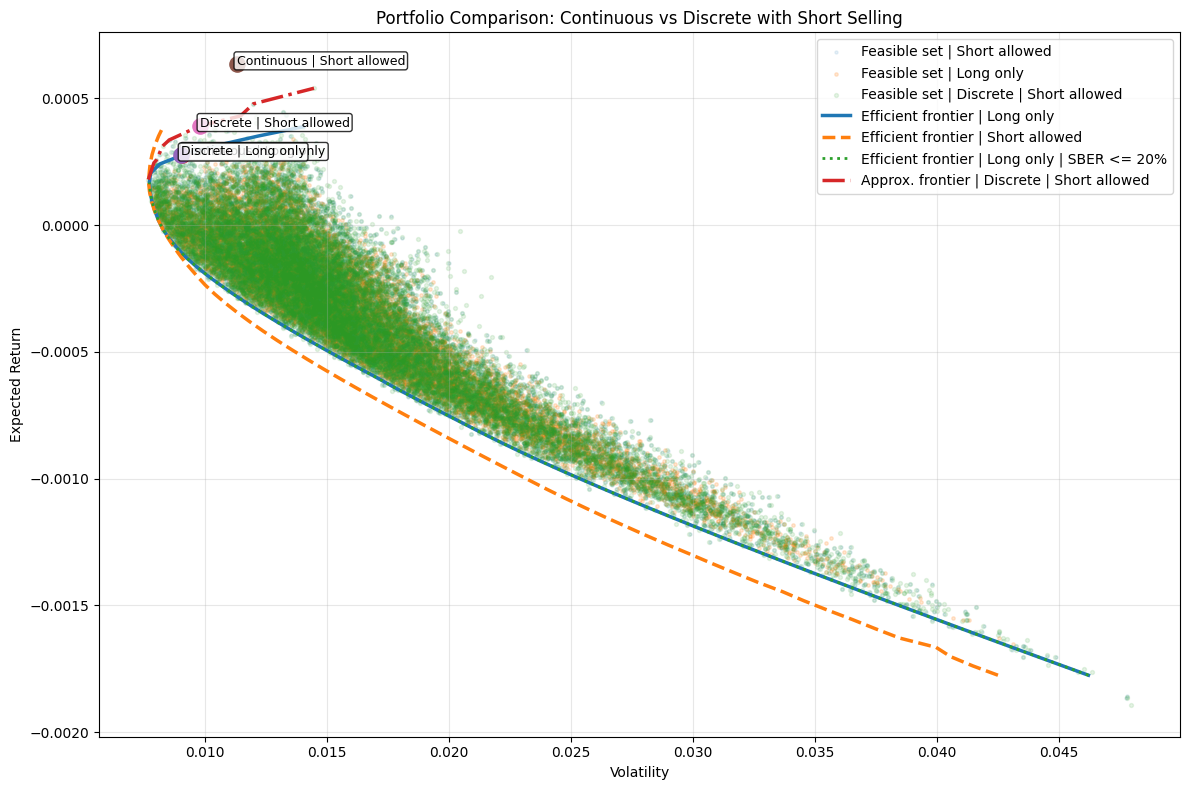

In [ ]:

plt.figure(figsize=(12, 8))

plt.scatter(
    random_short["volatility"],
    random_short["return"],
    s=5,
    alpha=0.10,
    label="Feasible set | Short allowed"
)

plt.scatter(
    random_long["volatility"],
    random_long["return"],
    s=6,
    alpha=0.18,
    label="Feasible set | Long only"
)

plt.scatter(
    random_discrete_short["volatility"],
    random_discrete_short["return"],
    s=8,
    alpha=0.12,
    label="Feasible set | Discrete | Short allowed"
)

plt.plot(
    frontier_long["volatility"],
    frontier_long["return"],
    linewidth=2.5,
    label="Efficient frontier | Long only"
)

plt.plot(
    frontier_short["volatility"],
    frontier_short["return"],
    linewidth=2.5,
    linestyle="--",
    label="Efficient frontier | Short allowed"
)

plt.plot(
    frontier_long_cap["volatility"],
    frontier_long_cap["return"],
    linewidth=2.0,
    linestyle=":",
    label="Efficient frontier | Long only | SBER <= 20%"
)

plt.plot(
    frontier_discrete_short["volatility"],
    frontier_discrete_short["return"],
    linewidth=2.5,
    linestyle="-.",
    label="Approx. frontier | Discrete | Short allowed"
)

texts = []

for _, row in portfolios_df.iterrows():
    x = row["Volatility"]
    y = row["Expected Return"]

    plt.scatter(x, y, s=120, zorder=3)

    txt = plt.text(
        x,
        y,
        row["Portfolio"],
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8)
    )
    texts.append(txt)

if adjust_text is not None:
    adjust_text(
        texts,
        x=portfolios_df["Volatility"].values,
        y=portfolios_df["Expected Return"].values,
        arrowprops=dict(arrowstyle="-", lw=0.8, alpha=0.6),
        force_text=(1.2, 1.2),
        force_static=(1.0, 1.0),
        expand_text=(1.2, 1.4),
        expand_points=(1.2, 1.4),
        ensure_inside_axes=True
    )

plt.title("Portfolio Comparison: Continuous vs Discrete with Short Selling")
plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
